## Problématique

## Analyse Exploratoire de Données 

#### Import des bibliothèques 

In [2]:
import pandas as pd
import numpy as np 
import seaborn as sn 
import matplotlib.pyplot as plt
import missingno as msno

In [3]:
df = pd.read_csv('database.csv')
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [4]:
df.info()
print('=='*50)
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  str    
 1   Time                        23412 non-null  str    
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  str    
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  str    
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         1604 non-null 

(23412, 21)

In [5]:
df.describe(include='all')

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
count,23412,23412,23412.000000,23412.000000,23412,23412.000000,4461.000000,7097.000000,23412.000000,23409,...,2564.000000,7299.000000,1604.000000,1156.000000,17352.000000,23412,23412,23412,23412,23412
unique,12401,20472,NaN,NaN,4,NaN,NaN,NaN,NaN,10,...,NaN,NaN,NaN,NaN,NaN,23412,13,48,24,2
top,03/11/2011,02:56:58,NaN,NaN,Earthquake,NaN,NaN,NaN,NaN,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,US,US,US,Reviewed
freq,128,5,NaN,NaN,23232,NaN,NaN,NaN,NaN,7722,...,NaN,NaN,NaN,NaN,NaN,1,20630,20350,10458,20773
mean,NaN,NaN,1.679033,39.639961,NaN,70.767911,4.993115,275.364098,5.882531,NaN,...,48.944618,44.163532,3.992660,7.662759,1.022784,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,30.113183,125.511959,NaN,122.651898,4.875184,162.141631,0.423066,NaN,...,62.943106,32.141486,5.377262,10.430396,0.188545,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,-77.080000,-179.997000,NaN,-1.100000,0.000000,0.000000,5.500000,NaN,...,0.000000,0.000000,0.004505,0.085000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,-18.653000,-76.349750,NaN,14.522500,1.800000,146.000000,5.600000,NaN,...,10.000000,24.100000,0.968750,5.300000,0.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,-3.568500,103.982000,NaN,33.000000,3.500000,255.000000,5.700000,NaN,...,28.000000,36.000000,2.319500,6.700000,1.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,26.190750,145.026250,NaN,54.000000,6.300000,384.000000,6.000000,NaN,...,66.000000,54.000000,4.724500,8.100000,1.130000,NaN,NaN,NaN,NaN,NaN


#### Détection des valeurs manquantes 

In [6]:
somme = df.isnull().sum()

frequence = somme/len(df)*100

tableau= pd.DataFrame(
    {'somme':somme,
     'frequence':frequence}
)
print(tableau)

                            somme  frequence
Date                            0   0.000000
Time                            0   0.000000
Latitude                        0   0.000000
Longitude                       0   0.000000
Type                            0   0.000000
Depth                           0   0.000000
Depth Error                 18951  80.945669
Depth Seismic Stations      16315  69.686486
Magnitude                       0   0.000000
Magnitude Type                  3   0.012814
Magnitude Error             23085  98.603280
Magnitude Seismic Stations  20848  89.048351
Azimuthal Gap               16113  68.823680
Horizontal Distance         21808  93.148813
Horizontal Error            22256  95.062361
Root Mean Square             6060  25.884162
ID                              0   0.000000
Source                          0   0.000000
Location Source                 0   0.000000
Magnitude Source                0   0.000000
Status                          0   0.000000


<Axes: >

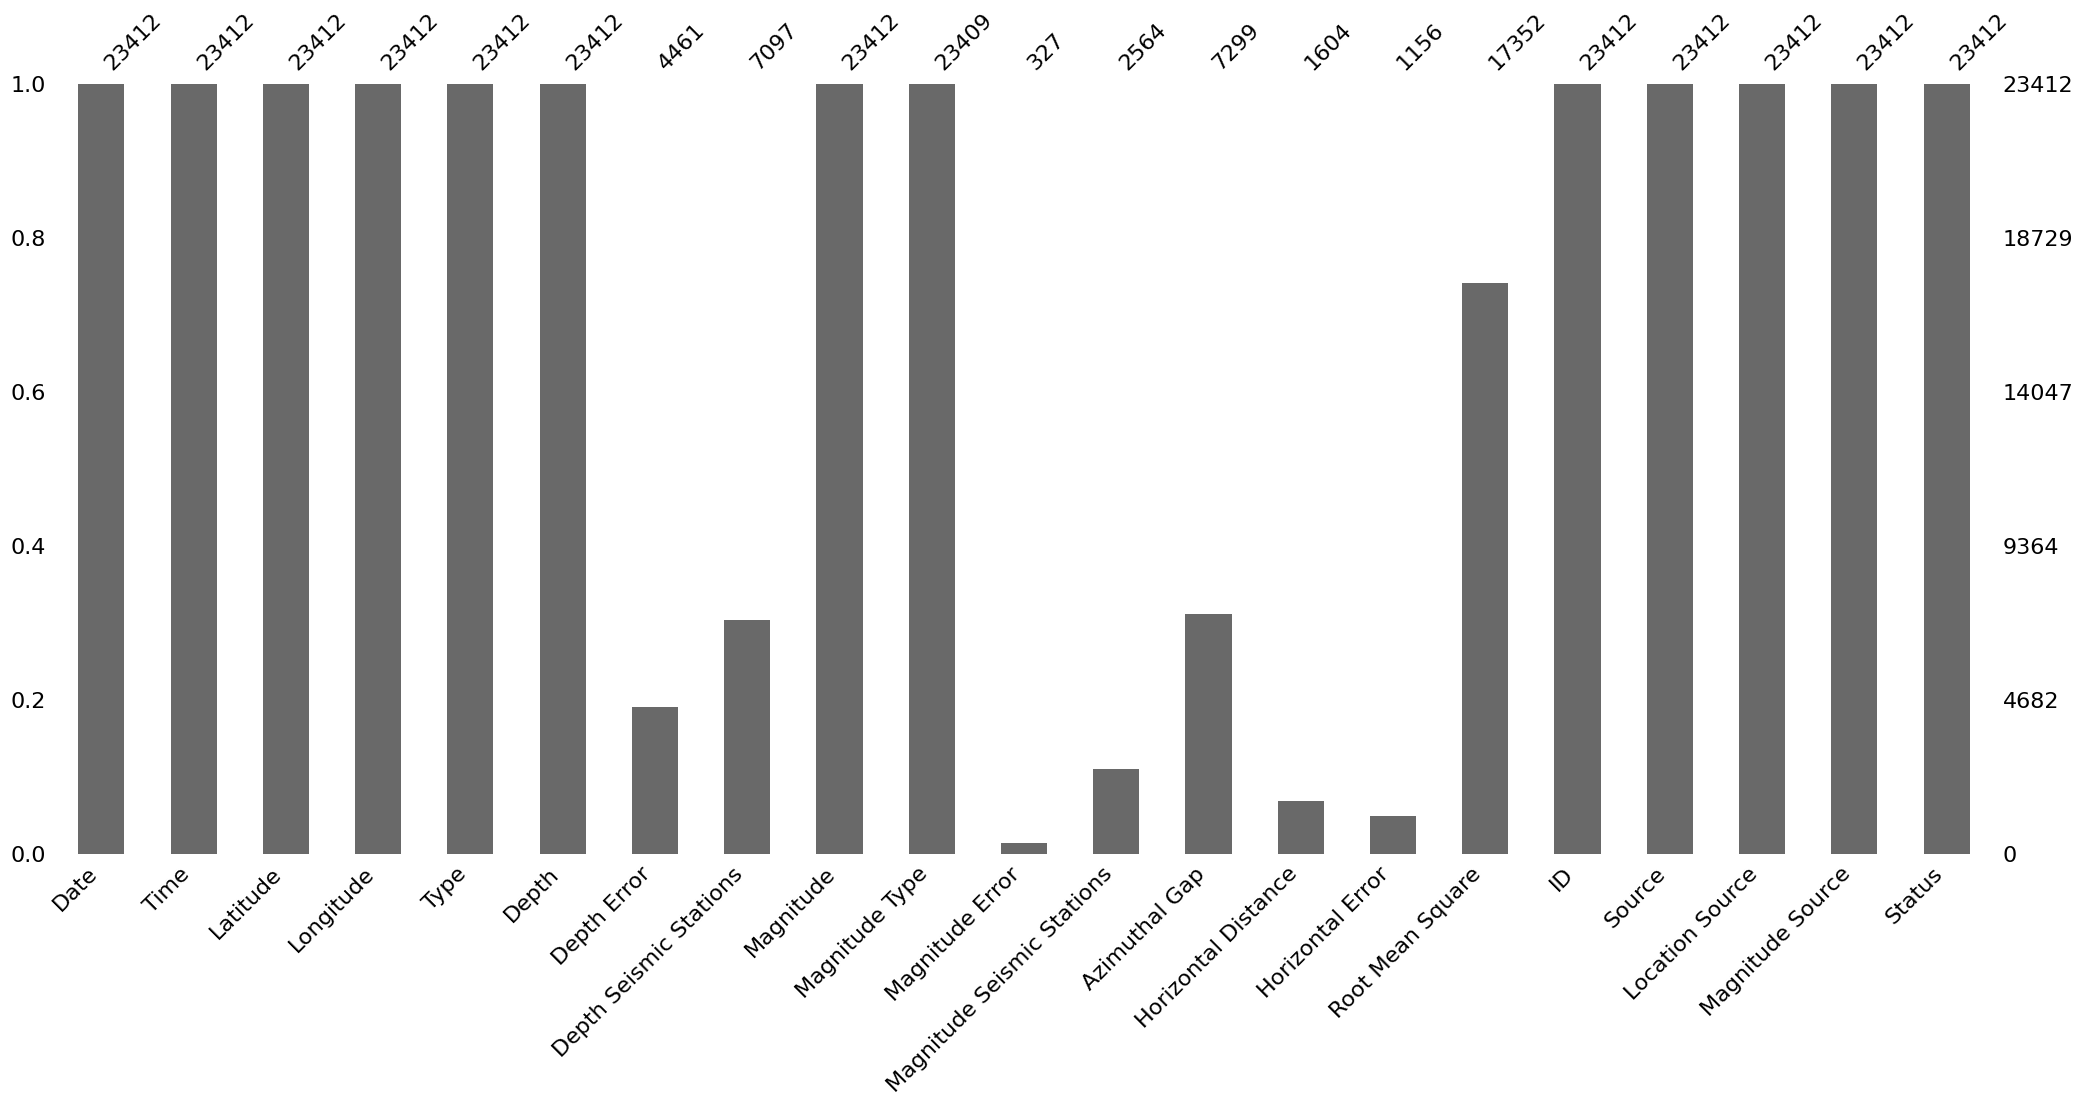

In [7]:
msno.bar(df)